In [13]:
# <finetuning_cleaned.py>

import os
import sys

import logging

# graphcast is in the parent directory so insert it into the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
import matplotlib.pyplot as plt
# import pynvml
import time

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")




# jax.config.update('jax_disable_jit', True)

# for memory efficiency
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

mean_by_level = None
stddev_by_level = None
diffs_stddev_by_level = None
model_config = None
task_config = None
params = None
state = None

def generate_sample_era5_dataset(
    date='2022-01-01', 
    model_config = None,
    task_config = None,
    time_steps=4
):
    """
    Generate a sample ERA5 dataset with random values matching original specifications.
    
    Parameters:
    - date: Base date for the dataset
    - lon_res: Longitude resolution
    - lat_res: Latitude resolution
    - levels: Number of vertical levels
    - time_steps: Number of time steps
    
    Returns:
    xr.Dataset with random values
    """
    lons = np.arange(0, 360, model_config.resolution)
    lats = np.arange(-90, 90 + model_config.resolution, model_config.resolution)
    # if task_config.levels == 13:
    level_values = np.array(task_config.pressure_levels)
    # level_values = np.array([1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, 150, 175, 200, 
    #                           225, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 
    #                           750, 775, 800, 825, 850, 875, 900, 925, 950, 975, 1000])
    times = pd.timedelta_range(start='0 days', periods=time_steps, freq='6h')
    
    base_datetime = pd.to_datetime(date)

    base_datetime = pd.to_datetime(date)
    datetime_coords = np.array([base_datetime + pd.Timedelta(t) for t in times])
    
    ds = xr.Dataset(
        data_vars={
            'geopotential_at_surface': (['lat', 'lon'], np.random.uniform(20000, 30000, size=(len(lats), len(lons)))),
            'land_sea_mask': (['lat', 'lon'], np.random.choice([0.0, 1.0], size=(len(lats), len(lons)))),
            '2m_temperature': (['batch', 'time', 'lat', 'lon'], np.random.uniform(240, 310, size=(1, len(times), len(lats), len(lons)))),
            'mean_sea_level_pressure': (['batch', 'time', 'lat', 'lon'], np.random.uniform(95000, 105000, size=(1, len(times), len(lats), len(lons)))),
            '10m_v_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            '10m_u_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            'total_precipitation_6hr': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(lats), len(lons)))),
            'toa_incident_solar_radiation': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 2000000, size=(1, len(times), len(lats), len(lons)))),
            'temperature': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(250, 300, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'geopotential': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 500000, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'u_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'v_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'vertical_velocity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-1, 1, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'specific_humidity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(level_values), len(lats), len(lons))))
        },
        coords={
            'lon': lons,
            'lat': lats,
            'level': level_values,
            'time': times,
            'datetime': (['batch', 'time'], datetime_coords.reshape(1, -1)),
            'batch': [0]
        }
    )
    
    return ds


# modify the gradients function signature (needed for finetuning with optax)
def grads_fn(params, state, inputs, targets, forcings, model_config, task_config):
    def _aux(params, state, i, t, f):
        (loss, diagnostics), next_state = setup_jax_functions.loss_fn.apply(params, state, jax.random.PRNGKey(0), model_config, task_config, i, t, f)
        return loss, (diagnostics, next_state)
    (loss, (diagnostics, next_state)), grads = jax.value_and_grad(_aux, has_aux=True)(params, state, inputs, targets, forcings)
    return loss, diagnostics, next_state, grads

def finetuning(train_inputs,train_targets,train_forcings,params):
    lr = 1e-4
    optimiser = optax.adam(lr, b1=0.9, b2=0.999, eps=1e-8)
    opt_state = optimiser.init(params)

    grads_fn_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn))
    
    print("Setting up grads function")
    
    state = {}
    loss, diagnostics, next_state, grads = grads_fn_jitted(params, state, train_inputs, train_targets, train_forcings)

    logger = logging.getLogger()

    print("Losses calculated, now updating")

    updates, opt_state = optimiser.update(grads, opt_state)

    print("Applying updates")

    params = optax.apply_updates(params, updates)

    return params, loss


def create_input_data(example_batch_, task_config_dict, index=0, lookahead=4):

    minibatch = example_batch_.isel(time=slice(index, index + lookahead))

    train_inputs, train_targets, train_forcings = data_utils.extract_inputs_targets_forcings(minibatch, target_lead_times=slice('6h', f'{12}h'), **task_config_dict)
    return train_inputs, train_targets, train_forcings


def daily_mean(data, input_data=False):
    return data.mean('time', keepdims=True)

def combinedata(first,second):
    return first.merge(second)


def train_graphcast(data, params, task_config_dict, epochs=10):

    device = jax.devices()[0]

    log_file = f"training_logs_{current_date}.log"
    logging.basicConfig(filename=log_file, level=logging.INFO, format="%(asctime)s - %(message)s")
    logger = logging.getLogger()

    logger.info(f"JAX is running on: {device}")
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)

    gpu_utilization = []
    gpu_memory = []


    params_path = os.path.join('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/local_files/params', f'params_finetune_test{current_date}.npz')

    loss_tracker = []
    lookahead = 5

    epoch_batch_loss = []

    for epoch in tqdm(range(epochs), desc="Training Epochs"):
        logger.info(f"Epoch number {epoch}")

        util = pynvml.nvmlDeviceGetUtilizationRates(handle)
        mem = pynvml.nvmlDeviceGetMemoryInfo(handle)
        
        gpu_utilization.append(util.gpu)           # in percent era5_temp_ppt2022_wb_1.0_regrid_all_vars.zarr
        gpu_memory.append(mem.used / 1024**2)      # in MB

        print(gpu_utilization)
        print(gpu_memory)
        
        time.sleep(1)

        for i in tqdm(range(data.dims.mapping['time']-3), desc="Training Batches"):
            logger.info(f"Time Batch number: {i}")
            
            # batches
            train_inputs, train_targets, train_forcings = create_input_data(data, task_config_dict=task_config_dict, index=i, lookahead = lookahead + 1)
            # combined_data = combiningData(train_targets, train_forcings)

            # train_inputs_mean_1_day = daily_mean(train_inputs)
            # train_targets_mean_1_day = daily_mean(train_targets)
            # train_forcings_mean_1_day = daily_mean(train_forcings)

            train_inputs_mean_1_day = train_inputs
            train_targets_mean_1_day = train_targets
            train_forcings_mean_1_day = train_forcings

            print("Train Inputs:  ", train_inputs_mean_1_day.sizes.mapping)
            print("Train Targets: ", train_targets_mean_1_day.sizes.mapping)
            print("Train Forcings:", train_forcings_mean_1_day.sizes.mapping)

            params, loss = finetuning(train_inputs_mean_1_day,train_targets_mean_1_day,train_forcings_mean_1_day, params)
            logger.info(f'\n =========== Loss for time batch number: {i} = {loss} =========== \n')
            print(f'\n =========== Loss for time batch number: {i} = {loss} =========== \n')
            loss_tracker.append(loss)
            epoch_batch_loss.append((epoch, i, loss)) 
            if i % 20 == 0 and i > 0:
                save_params_utils.save_model_params(params, f'{params_path}_{i}')

        logger.info(f'\n =========== Saving model after epoch {epoch} =========== \n')
        save_params_utils.save_model_params(params, params_path)

    pynvml.nvmlShutdown()
    plot_loss(epoch_batch_loss, current_date)
    plot_gpu_util(gpu_utilization, gpu_memory, current_date)

def plot_loss(epoch_batch_loss, date):
    """
    Plots the loss with epoch and batch number.
    """
    epochs = [entry[0] for entry in epoch_batch_loss]
    batches = [entry[1] for entry in epoch_batch_loss]
    losses = [entry[2] for entry in epoch_batch_loss]

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(losses)), losses, label="Loss")
    plt.xlabel("Epoch and Batch Number (Combined Index)")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch and Batch Number")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"plots/training/loss_plot{date}.png")
    plt.close()

def plot_gpu_util(gpu_utilization, gpu_memory, date):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(gpu_utilization, label='GPU Utilization (%)')
    plt.xlabel('Epoch')
    plt.ylabel('Utilization')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(gpu_memory, label='GPU Memory (MB)', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Memory Usage')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"plots/training/gpu_utilization_memory_plot{date}.png")
    plt.close()



In [2]:
import xarray as xr

In [44]:
%reset -f

In [4]:
# 

In [4]:
imd_targets_temp_ppt = xr.load_dataset("/Datastorage/saptarishi.dhanuka_asp25/imd_july2022_temp_ppt.grib", engine='cfgrib')
imd_targets_temp_ppt

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 838MB
Dimensions:            (time: 31, step: 13, latitude: 361, longitude: 720)
Coordinates:
    number             int64 8B 0
  * time               (time) datetime64[ns] 248B 2022-07-01 ... 2022-07-31
  * step               (step) timedelta64[ns] 104B 0 days 00:00:00 ... 3 days...
    heightAboveGround  float64 8B 2.0
  * latitude           (latitude) float64 3kB 90.0 89.5 89.0 ... -89.5 -90.0
  * longitude          (longitude) float64 6kB 0.0 0.5 1.0 ... 358.5 359.0 359.5
    valid_time         (time, step) datetime64[ns] 3kB 2022-07-01 ... 2022-08-03
    surface            float64 8B 0.0
Data variables:
    t2m                (time, step, latitude, longitude) float32 419MB 273.3 ...
    tp                 (time, step, latitude, longitude) float32 419MB 0.0 .....
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-04-21T13:12 GRIB to CDM+CF via cfgrib-0.9.1...

In [10]:
imd_targets_temp_ppt.isel(time=0, step=2)['tp']

<xarray.DataArray 'tp' (latitude: 361, longitude: 720)> Size: 1MB
array([[0.6875, 0.6875, 0.6875, ..., 0.6875, 0.6875, 0.6875],
       [0.3125, 0.375 , 0.375 , ..., 0.3125, 0.3125, 0.3125],
       [0.125 , 0.125 , 0.125 , ..., 0.1875, 0.1875, 0.125 ],
       ...,
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ]],
      dtype=float32)
Coordinates:
    number             int64 8B 0
    time               datetime64[ns] 8B 2022-07-01
    step               timedelta64[ns] 8B 12:00:00
    heightAboveGround  float64 8B 2.0
  * latitude           (latitude) float64 3kB 90.0 89.5 89.0 ... -89.5 -90.0
  * longitude          (longitude) float64 6kB 0.0 0.5 1.0 ... 358.5 359.0 359.5
    valid_time         datetime64[ns] 8B 2022-07-01T12:00:00
    surface            float64 8B 0.0
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         21
    GRIB_units:                               kg m**-2
    long_name:                                Total Precipitation
    units:                                    kg m**-2
    standard_name:                            unknown

In [16]:
wb_data = xr.open_zarr("/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_jun22_full.zarr")
wb_data.isel(time=slice(7,71))

<xarray.Dataset> Size: 1GB
Dimensions:                  (time: 61, latitude: 181, longitude: 361, level: 13)
Coordinates:
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 359.0 360.0
  * time                     (time) datetime64[ns] 488B 2022-06-15T18:00:00 ....
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 16MB dask.array<chunksize=(1, 181, 361), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 16MB dask.array<chunksize=(1, 181, 361), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 16MB dask.array<chunksize=(1, 181, 361), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 207MB dask.array<chunksize=(1, 13, 181, 361), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude) float32 261kB dask.array<chunksize=(181, 361), meta=np.ndarray>
    land_sea_mask            (latitude, longitude) float32 261kB dask.array<chunksize=(181, 361), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 207MB dask.array<chunksize=(1, 13, 181, 361), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 207MB dask.array<chunksize=(1, 13, 181, 361), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float32 16MB dask.array<chunksize=(1, 181, 361), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 207MB dask.array<chunksize=(1, 13, 181, 361), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 207MB dask.array<chunksize=(1, 13, 181, 361), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 207MB dask.array<chunksize=(1, 13, 181, 361), meta=np.ndarray>

In [18]:

# parser = argparse.ArgumentParser()
# parser.add_argument('--model_levels', default=13, type=int, choices=[13, 37], help='Number of Pressure Levels')
# parser.add_argument('--model_resolution', default=1.0, type=float, choices=[1.0, 0.25], help='Model Resolution')
# parser.add_argument('--data_type', default='fake', type=str, choices=['fake', 'era5_1', 'era5_0.25'])
# parser.add_argument('--data_path', default=None, help='Path to load era5 data from if necessary')
# parser.add_argument('--means_path', default='./', help='Path to load mean and stdev for scaling from')
global mean_by_level
global stddev_by_level
global diffs_stddev_by_level
global model_config
global task_config
global params
global state

log_file = f"loggers/printing_logs{current_date}.log"
logging.basicConfig(filename=log_file, level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger()
logger.info("Starting the script")



# args = parser.parse_args()
model_levels = 13
model_resolution = 1.0
if model_levels == 37:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_37.npz'
        
elif model_resolution == 0.25:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_13.npz'
    
    with open(f'/Datastorage/saptarishi.dhanuka_asp25/era5_data/graphcast_dataset_source-era5_date-2022-01-01_res-{args.model_resolution}_levels-13_steps-12.nc', 'rb') as f:
        logger.info("Loading Dataset")
        tik = datetime.now()
        training_trial_batch = xr.load_dataset(f).compute()
        tok = datetime.now()
        logger.info(f"Dataset loaded in {tok - tik}")

else:

    
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'
    dataset_name = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/arco_era5_1.0_formatted.nc"

    arco = wb_data
    
    old_lats = arco['latitude'].values
    old_lons = arco['longitude'].values
    new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
    new_lats = np.flip(new_lats)
    new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
    arco = arco.interp({'latitude': new_lats, 'longitude': new_lons}, 
                            method='linear',
                            kwargs={'fill_value': None})
    
    input_vars = ['10m_u_component_of_wind',
                'geopotential_at_surface',
                '10m_v_component_of_wind',
                'specific_humidity',
                'land_sea_mask',
                'vertical_velocity',
                'geopotential',
                'v_component_of_wind',
                'temperature',
                'total_precipitation_6hr',
                'mean_sea_level_pressure',
                '2m_temperature',
                'u_component_of_wind']
    
    # arco = arco.drop_vars(['toa_incident_solar_radiation',
    # 'year_progress_sin',
    # 'year_progress_cos',
    # 'day_progress_sin',
    # 'day_progress_cos','cos_latitude',
    # 'cos_longitude','sin_longitude'])

    # arco = arco.rename({'total_precipitation': 'total_precipitation_6hr'})

    arco = arco.expand_dims(batch=1)
    arco = arco.rename({'latitude': 'lat', 'longitude': 'lon'})

    datetime_array = arco['time'].values
    # Calculate the time coordinate in 6-hour increments (in nanoseconarco)
    time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

    # Add the new 'time' coordinate to the dataset
    arco1 = arco.assign_coords(datetime=('time', time_array))

    temp_time = arco1.coords["time"].copy()
    temp_datetime = arco1.coords["datetime"].copy()

    # Reassign the coordinates, swapping their values
    arco1 = arco1.assign_coords(
        time=temp_datetime,
        datetime=temp_time
    )

    logger.info("Coordinates first time")
    logger.info(arco1)
    logger.info("\n")
    logger.info(arco1.coords)
    logger.info("\n")


    # arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
    # arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

    old_datetime = arco1["datetime"].values  # shape (1489,)

    # For our purposes, we want the coordinate to have shape (batch, time). Since the batch
    # dimension is of length 1, we can simply add a new axis.
    new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

    # Now, reassign the "datetime" coordinate to have dims ("batch", "time").
    arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

    print(f"Coordinates after reassigning: {arco1.coords}\n")


    logger.info(arco1.nbytes)

    select_time = arco1.isel(time=slice(0, 240))
    tik = datetime.now()

    select_time_eval = arco1.isel(time=slice(7,71))

    eval_trial_batch = select_time_eval.load()

    print(f"Eval batch first time: {eval_trial_batch.time.values}")
    # training_trial_batch = select_time.load()

    tok = datetime.now()
    # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    logger.info("Training batch time")
    # logger.info(training_trial_batch.coords)
    logger.info(f"Dataset loaded in {tok - tik}")

    # with open("/Datastorage/saptarishi.dhanuka_asp25/era5_data/dataset_source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc", 'rb') as f:
    #     print("Loading Dataset")
    #     tik = datetime.now()
    #     training_trial_batch = xr.load_dataset(f).compute()
    #     # training_trial_batch = training_trial_batch.isel(time=slice(0, 12))
    #     # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    #     print("Training batch time")
    #     print(training_trial_batch.datetime)
    #     tok = datetime.now()
    #     print(f"Dataset loaded in {tok - tik}")


with open(filename, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params


with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()


state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
logger.info(model_config)
logger.info(task_config)
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
    'params': ckpt.params,
    'state': {},
    'model_config': ckpt.model_config,
    'task_config': ckpt.task_config,
    'mean_by_level': mean_by_level,
    'stddev_by_level': stddev_by_level,
    'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
    setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=inputs,
        targets_template=targets_template,
        forcings=forcings,
        params=params,
        state=state
    )
    return predictions


Coordinates after reassigning: Coordinates:
  * level     (level) int64 104B 50 100 150 200 250 300 ... 600 700 850 925 1000
  * lat       (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (batch, time) datetime64[ns] 544B 2022-06-14 ... 2022-06-30T18:...
  * time      (time) timedelta64[ns] 544B 0 days 00:00:00 ... 16 days 18:00:00

Eval batch first time: [ 151200000000000  172800000000000  194400000000000  216000000000000
  237600000000000  259200000000000  280800000000000  302400000000000
  324000000000000  345600000000000  367200000000000  388800000000000
  410400000000000  432000000000000  453600000000000  475200000000000
  496800000000000  518400000000000  540000000000000  561600000000000
  583200000000000  604800000000000  626400000000000  648000000000000
  669600000000000  691200000000000  712800000000000  734400000000000
  756000000000000  777600000000000  799200000000

In [19]:
eval_trial_batch

<xarray.Dataset> Size: 3GB
Dimensions:                  (batch: 1, time: 61, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 488B 2022-06-15T18:...
  * time                     (time) timedelta64[ns] 488B 1 days 18:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 32MB 0.1858 ... ...
    10m_v_component_of_wind  (batch, time, lat, lon) float64 32MB -0.1171 ......
    2m_temperature           (batch, time, lat, lon) float64 32MB 273.6 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 413MB 2.0...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 413MB 3.0...
    temperature              (batch, time, level, lat, lon) float64 413MB 230...
    total_precipitation_6hr  (batch, time, lat, lon) float64 32MB 0.0009866 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 413MB 1.5...
    v_component_of_wind      (batch, time, level, lat, lon) float64 413MB 0.0...
    vertical_velocity        (batch, time, level, lat, lon) float64 413MB 0.0...

In [22]:
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_trial_batch, target_lead_times=slice("6h", "168h"),
**dataclasses.asdict(task_config))

In [6]:
eval_targets

<xarray.Dataset> Size: 2GB
Dimensions:                  (batch: 1, time: 56, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) timedelta64[ns] 448B 0 days 06:00:00 ... ...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float64 29MB 273.0 ... 2...
    mean_sea_level_pressure  (batch, time, lat, lon) float64 29MB 1.003e+05 ....
    10m_v_component_of_wind  (batch, time, lat, lon) float64 29MB -0.0154 ......
    10m_u_component_of_wind  (batch, time, lat, lon) float64 29MB -0.4556 ......
    total_precipitation_6hr  (batch, time, lat, lon) float64 29MB 0.0001441 ....
    temperature              (batch, time, level, lat, lon) float64 379MB 232...
    geopotential             (batch, time, level, lat, lon) float64 379MB 2.0...
    u_component_of_wind      (batch, time, level, lat, lon) float64 379MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 379MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float64 379MB -0....
    specific_humidity        (batch, time, level, lat, lon) float64 379MB 3.0...

In [17]:
# since we did target lead times as 6h 60h we used 6h as inputs and from 6h onwards till 60 h later. So since the eval_trial_batch is from 2022-06-01, the eval targets start from 2022-06-15 06:00:00 and go till 2022-06-17 12:00:00
eval_targets

<xarray.Dataset> Size: 433MB
Dimensions:                  (batch: 1, time: 10, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) timedelta64[ns] 80B 0 days 06:00:00 ... 2...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float64 5MB 273.3 ... 226.8
    mean_sea_level_pressure  (batch, time, lat, lon) float64 5MB 1.006e+05 .....
    10m_v_component_of_wind  (batch, time, lat, lon) float64 5MB -0.1081 ... ...
    10m_u_component_of_wind  (batch, time, lat, lon) float64 5MB 0.002005 ......
    total_precipitation_6hr  (batch, time, lat, lon) float64 5MB 0.0001071 .....
    temperature              (batch, time, level, lat, lon) float64 68MB 230....
    geopotential             (batch, time, level, lat, lon) float64 68MB 2.04...
    u_component_of_wind      (batch, time, level, lat, lon) float64 68MB 0.00...
    v_component_of_wind      (batch, time, level, lat, lon) float64 68MB -0.0...
    vertical_velocity        (batch, time, level, lat, lon) float64 68MB 0.00...
    specific_humidity        (batch, time, level, lat, lon) float64 68MB 3.09...

In [20]:
jax.config.update("jax_enable_x64", True)

In [23]:

# training_trial_batch = generate_sample_era5_dataset(model_config=model_config, task_config=task_config, time_steps = 10)

assert eval_trial_batch.sizes["time"] >= 3

logger.info(f"Eval batch time dimensions: {eval_trial_batch.sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)
# task_config_dict.pop('input_duration')

logger.info("Starting training")

# train_graphcast(training_trial_batch, params, task_config_dict, epochs=3)


print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

# print("Running chunked predictions")

# predictions = rollout.chunked_prediction(
# run_forward_jitted,
# rng=jax.random.PRNGKey(0),
# inputs=eval_inputs,
# targets_template=eval_targets * np.nan,
# forcings=eval_forcings)

# print("Predictions:   ", predictions.dims.mapping)
# predictions.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/predictions.nc")



new_params_path = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz"

f = open(new_params_path, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params

# new_params = save_params_utils.load_model_params(new_params_path)

print("Loaded New Params: ", new_params.keys())

targets_template = eval_targets * np.nan

print("Running old params")
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)
# predictions_old.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/predictions_old.nc")

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Loaded New Params:  dict_keys(['grid2mesh_gnn/~_networks_builder/encoder_edges_grid2mesh_layer_norm', 'grid2mesh_gnn/~_networks_builder/encoder_edges_grid2mesh_mlp/~/linear_0', 'grid2mesh_gnn/~_networks_builder/encoder_edges_grid2mesh_mlp/~/linear_1', 'grid2mesh_gnn/~_networks_builder/encoder_nodes_grid_nodes_layer_norm', 'grid2mesh_gnn/~_networks_builder/encoder_nodes_grid_nodes_mlp/~/linear_0', 'grid2mesh_gnn/~_networks_builder/encoder_nodes_grid_nodes_mlp/~/linear_1', 'grid2mesh_gnn/~_networks_builder/encoder_nodes_mesh_nodes_layer_norm', 'grid2mesh_gnn/~_networks_builder/encoder_nodes_mesh_nodes_mlp/~/linear_0', 'grid2mesh_gnn/~_networks_builder/encoder_nodes_mesh_nodes_mlp/~/linear_1', 'grid2mesh_gnn/~_networks_builder/processor_edges_0_grid2mesh_layer_norm', 'grid

/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']


Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [24]:
print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)
# predictions_finetuned.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/predictions_finetuned.nc")

Running new params


/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']


Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [25]:
predictions_old.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/predictions_old.nc")
predictions_finetuned.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/predictions_finetuned.nc")


In [ ]:
# import xarray as xr 
# import numpy as np

# predictions_old = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/predictions_old.nc")
# predictions_finetuned = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/predictions_finetuned.nc")
# predictions_old

/tmp/ipykernel_350039/2019814633.py:4: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/predictions_old.nc")
/tmp/ipykernel_350039/2019814633.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/predictions_finetuned.nc")


<xarray.Dataset> Size: 216MB
Dimensions:                  (time: 10, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 80B 0 days 06:00:00 ... 2...
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 3MB ...
    10m_v_component_of_wind  (time, batch, lat, lon) float32 3MB ...
    2m_temperature           (time, batch, lat, lon) float32 3MB ...
    geopotential             (time, batch, level, lat, lon) float32 34MB ...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 3MB ...
    specific_humidity        (time, batch, level, lat, lon) float32 34MB ...
    temperature              (time, batch, level, lat, lon) float32 34MB ...
    total_precipitation_6hr  (time, batch, lat, lon) float32 3MB ...
    u_component_of_wind      (time, batch, level, lat, lon) float32 34MB ...
    v_component_of_wind      (time, batch, level, lat, lon) float32 34MB ...
    vertical_velocity        (time, batch, level, lat, lon) float32 34MB ...

In [26]:
import cartopy.crs as ccrs

# Extract the variable of interest (e.g., '2m_temperature')
variable_name = '2m_temperature'
temperature_pred_old = predictions_old[variable_name]
temperature_pred_finetuned = predictions_finetuned[variable_name]
temperature_targets = eval_targets[variable_name]

In [20]:
temperature_targets

<xarray.DataArray '2m_temperature' (batch: 1, time: 10, lat: 181, lon: 360)> Size: 5MB
array([[[[273.31552124, 273.31552124, 273.31552124, ..., 273.31552124,
          273.31552124, 273.31552124],
         [273.38076782, 273.38430786, 273.38607788, ..., 273.38781738,
          273.38607788, 273.38430786],
         [273.48309326, 273.48309326, 273.48309326, ..., 273.4671936 ,
          273.46896362, 273.47601318],
         ...,
         [224.30093384, 224.32034302, 224.3397522 , ..., 224.18453979,
          224.2074585 , 224.25508118],
         [223.62187195, 223.63775635, 223.65362549, ..., 223.56896973,
          223.58659363, 223.60423279],
         [224.19158936, 224.19158936, 224.19158936, ..., 224.19158936,
          224.19158936, 224.19158936]],

        [[273.19204712, 273.19204712, 273.19204712, ..., 273.19204712,
          273.19204712, 273.19204712],
         [273.36489868, 273.35784912, 273.35256958, ..., 273.3772583 ,
          273.37371826, 273.37017822],
         [273.55010986, 273.53424072, 273.51834106, ..., 273.53424072,
          273.53952026, 273.5447998 ],
...
         [231.30062866, 231.30776978, 231.31846619, ..., 231.2310791 ,
          231.2542572 , 231.27566528],
         [231.5539093 , 231.57174683, 231.58956909, ..., 231.53250122,
          231.54141235, 231.54676819],
         [230.48017883, 230.48017883, 230.48017883, ..., 230.48017883,
          230.48017883, 230.48017883]],

        [[273.59152222, 273.59152222, 273.59152222, ..., 273.59152222,
          273.59152222, 273.59152222],
         [273.29367065, 273.28829956, 273.284729  , ..., 273.31863403,
          273.3097229 , 273.30258179],
         [273.33111572, 273.32397461, 273.31863403, ..., 273.34893799,
          273.34002686, 273.3364563 ],
         ...,
         [226.65614319, 226.61512756, 226.57409668, ..., 226.71144104,
          226.69003296, 226.67398071],
         [226.15138245, 226.12463379, 226.09967041, ..., 226.26019287,
          226.22273254, 226.1870575 ],
         [226.76672363, 226.76672363, 226.76672363, ..., 226.76672363,
          226.76672363, 226.76672363]]]])
Coordinates:
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * time     (time) timedelta64[ns] 80B 0 days 06:00:00 ... 2 days 12:00:00
Dimensions without coordinates: batch
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

In [27]:
import xarray as xr
import numpy as np
imd_targets = xr.load_dataset("/Datastorage/saptarishi.dhanuka_asp25/_mars-bol-webmars-private-svc-blue-006-7a527896970b09a4fc90fa37bf98d3ff-ax1w8d.grib", engine='cfgrib')
old_lats = imd_targets['latitude'].values
old_lons = imd_targets['longitude'].values
new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
new_lats = np.flip(new_lats)
new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
imd_targets = imd_targets.interp({'latitude': new_lats, 'longitude': new_lons}, 
                        method='linear',
                        kwargs={'fill_value': None})
imd_targets

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 109MB
Dimensions:            (time: 30, step: 7, latitude: 181, longitude: 360)
Coordinates:
    number             int64 8B 0
  * time               (time) datetime64[ns] 240B 2022-06-01 ... 2022-06-30
  * step               (step) timedelta64[ns] 56B 00:00:00 ... 1 days 12:00:00
    heightAboveGround  float64 8B 2.0
    valid_time         (time, step) datetime64[ns] 2kB 2022-06-01 ... 2022-07...
  * latitude           (latitude) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * longitude          (longitude) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
Data variables:
    t2m                (time, step, latitude, longitude) float64 109MB 271.8 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-04-21T11:32 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
imd_target_init_15th = imd_targets.sel(time='2022-06-15T00:00:00.000000000')['t2m']
imd_target_init_15th = imd_target_init_15th.rename({'latitude': 'lat', 'longitude': 'lon'})
imd_target_init_15th

<xarray.DataArray 't2m' (step: 7, latitude: 181, longitude: 360)> Size: 4MB
array([[[273.56564331, 273.56564331, 273.56564331, ..., 273.56564331,
         273.56564331, 273.56564331],
        [273.44064331, 273.44064331, 273.44064331, ..., 273.43283081,
         273.44064331, 273.44064331],
        [273.37814331, 273.37814331, 273.38595581, ..., 273.37033081,
         273.37033081, 273.37814331],
        ...,
        [241.25314331, 241.30001831, 241.34689331, ..., 241.01095581,
         241.08908081, 241.17501831],
        [238.92501831, 238.95626831, 238.98751831, ..., 238.83126831,
         238.86251831, 238.90158081],
        [237.69064331, 237.69064331, 237.69064331, ..., 237.69064331,
         237.69064331, 237.69064331]],

       [[273.58450317, 273.58450317, 273.58450317, ..., 273.58450317,
         273.58450317, 273.58450317],
        [273.48294067, 273.48294067, 273.48294067, ..., 273.48294067,
         273.48294067, 273.48294067],
        [273.45169067, 273.45169067, 273.45169067, ..., 273.45950317,
         273.45950317, 273.45950317],
...
        [226.17796326, 226.17015076, 226.16233826, ..., 226.22483826,
         226.20921326, 226.19358826],
        [225.55296326, 225.54515076, 225.53733826, ..., 225.58421326,
         225.57640076, 225.56858826],
        [225.73265076, 225.73265076, 225.73265076, ..., 225.73265076,
         225.73265076, 225.73265076]],

       [[273.20001221, 273.20001221, 273.20001221, ..., 273.20001221,
         273.20001221, 273.20001221],
        [273.32501221, 273.32501221, 273.32501221, ..., 273.32501221,
         273.32501221, 273.32501221],
        [273.32501221, 273.32501221, 273.32501221, ..., 273.32501221,
         273.32501221, 273.32501221],
        ...,
        [224.94999695, 224.94999695, 224.94999695, ..., 224.94999695,
         224.94999695, 224.94999695],
        [224.32499695, 224.32499695, 224.32499695, ..., 224.32499695,
         224.32499695, 224.32499695],
        [224.44999695, 224.44999695, 224.44999695, ..., 224.44999695,
         224.44999695, 224.44999695]]])
Coordinates:
    number             int64 8B 0
    time               datetime64[ns] 8B 2022-06-15
  * step               (step) timedelta64[ns] 56B 00:00:00 ... 1 days 12:00:00
    heightAboveGround  float64 8B 2.0
    valid_time         (step) datetime64[ns] 56B 2022-06-15 ... 2022-06-16T12...
  * latitude           (latitude) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * longitude          (longitude) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            cf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         21
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            air_temperature

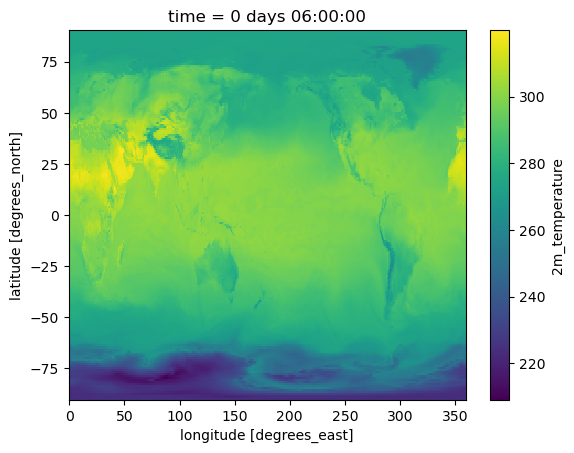

In [26]:
temperature_pred_old.isel(time=0).plot()

In [17]:
temperature_pred_finetuned.isel(time=0).squeeze()

<xarray.DataArray '2m_temperature' (lat: 181, lon: 360)> Size: 261kB
xarray_jax.JaxArrayWrapper(Array([[273.67465, 273.67593, 273.66574, ..., 273.6447 , 273.66318,
        273.6613 ],
       [273.51477, 273.5162 , 273.53323, ..., 273.48315, 273.49814,
        273.49646],
       [273.48645, 273.487  , 273.49634, ..., 273.45673, 273.48645,
        273.48615],
       ...,
       [224.31064, 224.30536, 224.33731, ..., 224.1558 , 224.17973,
        224.25714],
       [224.30734, 224.33165, 224.3679 , ..., 224.28717, 224.2503 ,
        224.295  ],
       [224.70003, 224.75609, 224.7459 , ..., 224.67964, 224.72041,
        224.70512]], dtype=float32))
Coordinates:
    time     timedelta64[ns] 8B 06:00:00
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0

In [51]:
temperature_pred_finetuned.isel(time=0)

<xarray.DataArray '2m_temperature' (batch: 1, lat: 181, lon: 360)> Size: 261kB
xarray_jax.JaxArrayWrapper(Array([[[273.67465, 273.67593, 273.66574, ..., 273.6447 , 273.66318,
         273.6613 ],
        [273.51477, 273.5162 , 273.53323, ..., 273.48315, 273.49814,
         273.49646],
        [273.48645, 273.487  , 273.49634, ..., 273.45673, 273.48645,
         273.48615],
        ...,
        [224.31064, 224.30536, 224.33731, ..., 224.1558 , 224.17973,
         224.25714],
        [224.30734, 224.33165, 224.3679 , ..., 224.28717, 224.2503 ,
         224.295  ],
        [224.70003, 224.75609, 224.7459 , ..., 224.67964, 224.72041,
         224.70512]]], dtype=float32))
Coordinates:
    time     timedelta64[ns] 8B 06:00:00
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Dimensions without coordinates: batch

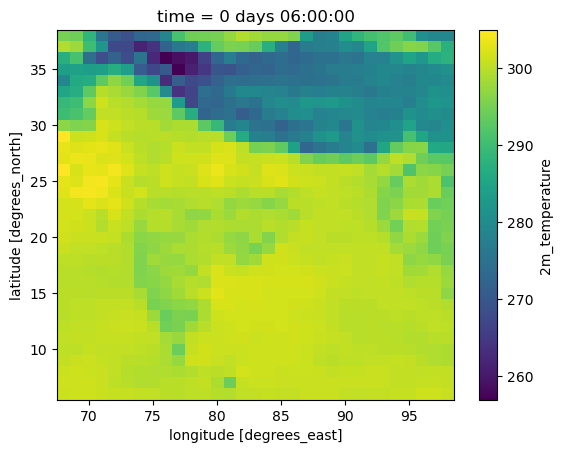

In [27]:
latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

temperature_pred_finetuned.isel(time=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze().plot()

In [32]:
diff = temperature_pred_finetuned.isel(time=0).squeeze() - imd_target_init_15th.isel(step=0).squeeze()
diff

<xarray.DataArray (lat: 181, lon: 360)> Size: 521kB
xarray_jax.JaxArrayWrapper(Array([[  0.75751159,   0.77025109,   0.77407294, ...,   0.76706622,
          0.77916874,   0.76897714],
       [  0.53350897,   0.5453784 ,   0.55933018, ...,   0.59408127,
          0.56840232,   0.55603619],
       [  0.75155007,   0.74844379,   0.72481603, ...,   0.76946134,
          0.77757123,   0.77404613],
       ...,
       [-11.9306769 , -12.0581418 , -12.0514381 , ..., -11.77657077,
        -11.86805801, -11.91940002],
       [-11.35475818, -11.39629261, -11.43955127, ..., -11.11751329,
        -11.17902909, -11.37067183],
       [-11.50633139, -11.52671459, -11.50633139, ..., -11.49613979,
        -11.50633139, -11.49613979]], dtype=float64))
Coordinates:
  * lat                (lat) float64 1kB 90.0 89.0 88.0 ... -88.0 -89.0 -90.0
  * lon                (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    number             int64 8B 0
    step               timedelta64[ns] 8B 00:00:00
    heightAboveGround  float64 8B 2.0
    valid_time         datetime64[ns] 8B 2022-06-15

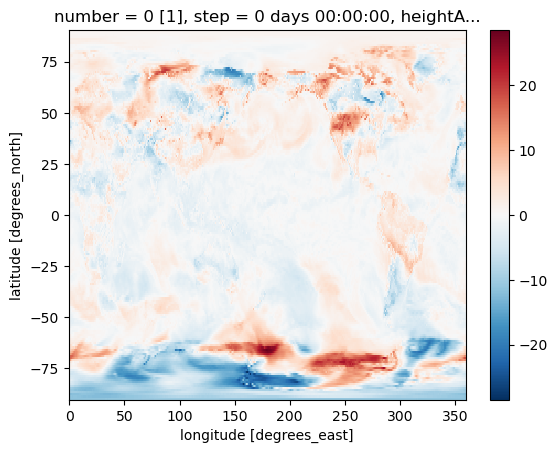

In [33]:
diff.plot()

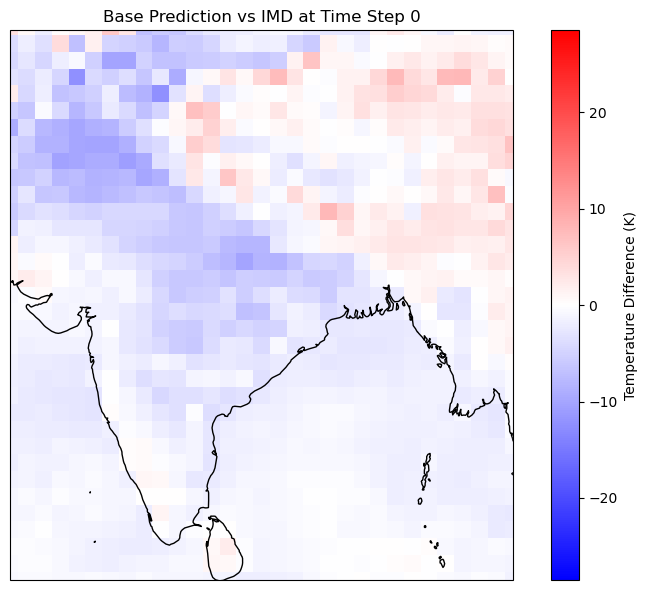

In [50]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
extent = [68, 98, 6, 38]  # Focus on India

# Difference between finetuned predictions and evaluation targets
temp_old = temperature_pred_old.isel(time=0).squeeze()
temp_targets = imd_target_init_15th.isel(step=0).squeeze()
difference = temp_old - temp_targets

difference.plot.pcolormesh(
    ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
    cbar_kwargs={'label': 'Temperature Difference (K)'})
ax.set_extent(extent)
ax.coastlines()
ax.set_title(f"Base Prediction vs IMD at Time Step {0}")

plt.tight_layout()
plt.show()

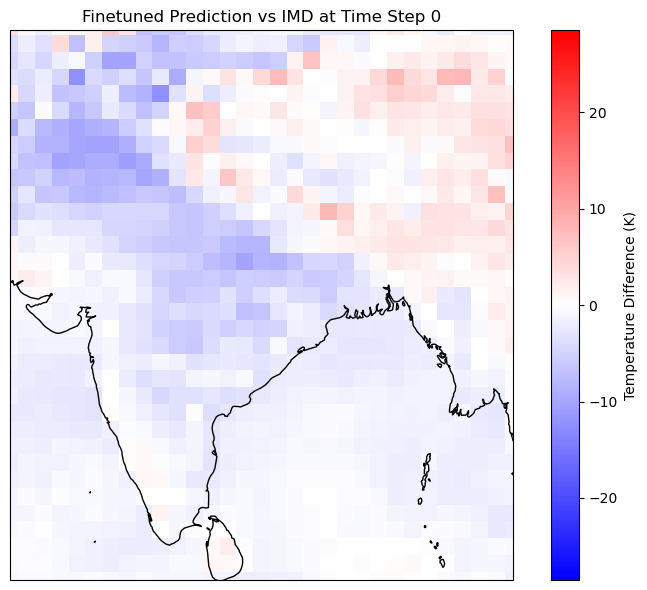

In [51]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
extent = [68, 98, 6, 38]  # Focus on India

# Difference between finetuned predictions and evaluation targets
temp_finetuned = temperature_pred_old.isel(time=0).squeeze()
temp_targets = imd_target_init_15th.isel(step=0).squeeze()
difference = temp_finetuned - temp_targets

difference.plot.pcolormesh(
    ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
    cbar_kwargs={'label': 'Temperature Difference (K)'})
ax.set_extent(extent)
ax.coastlines()
ax.set_title(f"Finetuned Prediction vs IMD at Time Step {0}")

plt.tight_layout()
plt.show()

100%|██████████| 7/7 [00:01<00:00,  4.46it/s]


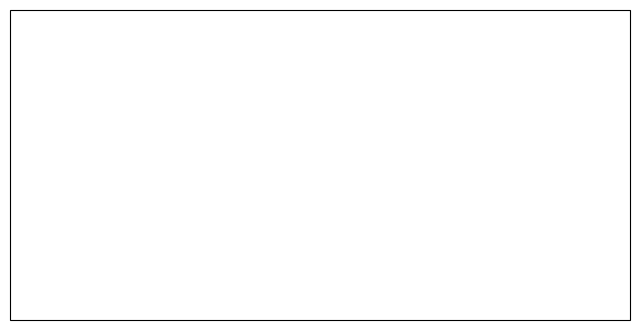

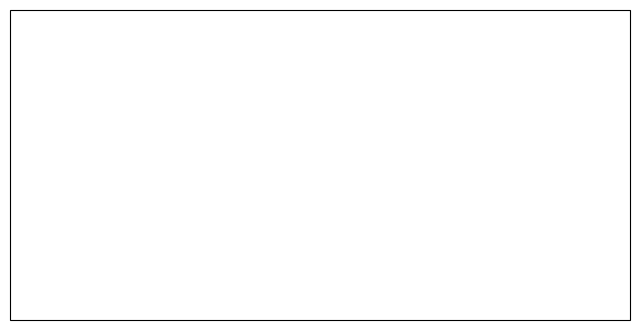

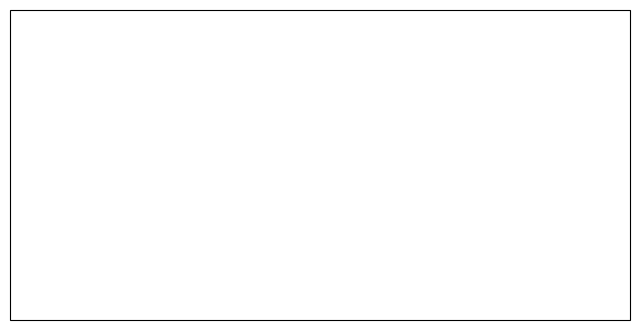

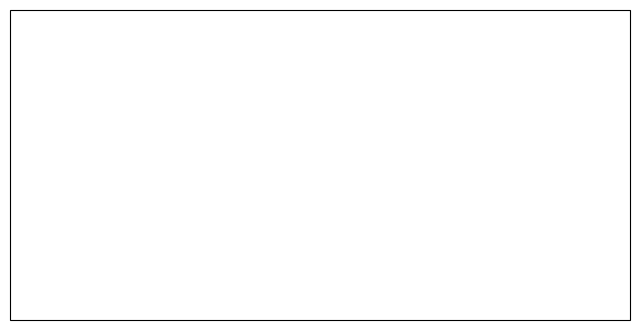

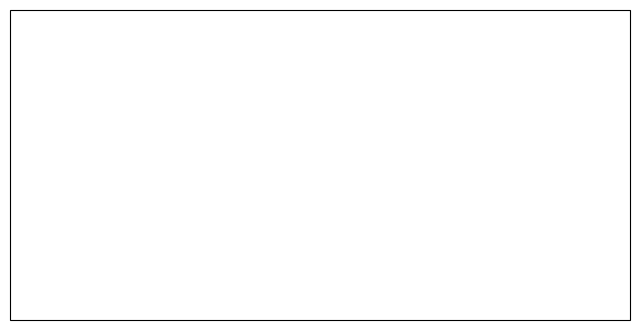

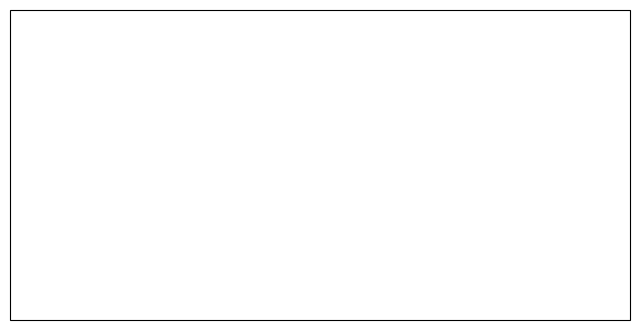

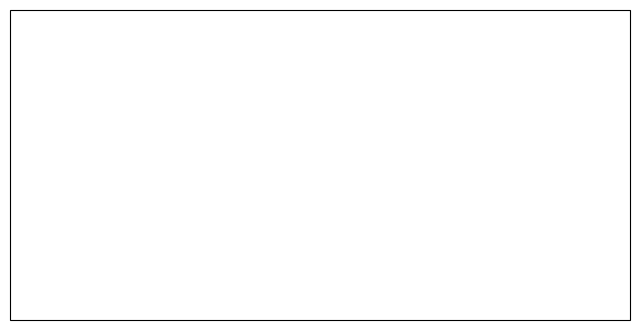

In [34]:
from tqdm import tqdm
# Define the time steps to visualize
time_steps = list(range(7))  # Adjust as needed

extent = [68, 98, 6, 38]  # Focus on India
latmax = 38
latmin = 6
lonmax = 98
lonmin = 68


# Function to plot predictions over India
def plot_predictions(time_step):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # Old predictions
    ax = axs[0]
    temp_old = temperature_pred_old.isel(time=time_step).squeeze()
    temp_old.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
        cbar_kwargs={'label': 'Temperature (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Old Predictions at Time Step {time_step}")

    # Finetuned predictions
    ax = axs[1]
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).squeeze()
    temp_finetuned.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
        cbar_kwargs={'label': 'Temperature (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Predictions at Time Step {time_step}")

    # Difference between finetuned and old predictions
    ax = axs[2]
    difference = temp_finetuned - temp_old
    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Difference at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plots/training/predictions_comparison{time_step}.png')
    plt.close()


# Function to plot difference between finetuned predictions and ground truth
def finetuned_diff_imd(time_step):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = imd_target_init_15th.isel(step=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs IMD at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plots/training/difference_finetuned{time_step}_imd.png')
    plt.close()

    return (difference)



def plot_difference_with_targets(time_step):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plots/training/difference_finetuned{time_step}.png')
    plt.close()

    return (difference)




# Function to plot difference between base predictions and ground truth
def base_diff_imd(time_step):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # Difference between finetuned predictions and evaluation targets
    temp_old = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = imd_target_init_15th.isel(step=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_old - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Base Prediction vs IMD at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plots/training/difference_base{time_step}_imd.png')
    plt.close()

    return (difference)


# Function to plot difference between base predictions and ground truth
def plot_diff_imd_era5(time_step):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # Difference between finetuned predictions and evaluation targets
    imd_pred = imd_target_init_15th.isel(step=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = imd_pred - temp_targets

    # difference.plot.pcolormesh(
    #     ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
    #     cbar_kwargs={'label': 'Temperature Difference (K)'})
    # ax.set_extent(extent)
    # ax.coastlines()
    # ax.set_title(f"ERA5 vs IMD at Time Step {time_step}")

    # plt.tight_layout()
    # plt.savefig(f'plots/training/difference_era5{time_step}_imd.png')
    # plt.close()

    return (difference)



# Plot differences with ground truth for each time step
differences_finetuned = []
differences_base = []
differences_era5_imd = []
for time_step in tqdm(time_steps):
    differences_finetuned.append(finetuned_diff_imd(time_step))
    differences_base.append(base_diff_imd(time_step))
    differences_era5_imd.append(plot_diff_imd_era5(time_step))

# print(differences_finetuned)
# print(differences_base)


def compute_mse(predictions, targets):
    return ((predictions - targets) ** 2).mean()

def compute_mse_diffs(diff):
    return (diff ** 2).mean(dim=["lat", "lon"]).values

# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []

# need to define the extent for india and then calculate metric


In [35]:
# Compute the mean absolute difference for each timestep and append to the lists

mse_finetuned = []
mse_base = []
for i in tqdm(range(len(differences_finetuned))):
    mse_diff_finetuned = compute_mse_diffs(differences_finetuned[i])
    mse_diff_base = compute_mse_diffs(differences_base[i])
    mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[i])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    mse_imd_era5.append(mse_diff_imd_era5)

100%|██████████| 7/7 [00:00<00:00, 31.44it/s]


In [40]:
# Compute the mean absolute difference for each timestep and append to the lists

mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for i in tqdm(range(len(differences_finetuned))):
    mean_abs_diff_finetuned = abs(differences_finetuned[i]).mean(dim=["lat", "lon"]).values
    mean_abs_diff_base = abs(differences_base[i]).mean(dim=["lat", "lon"]).values
    mean_abs_diff_imd_era5 = abs(differences_era5_imd[i]).mean(dim=["lat", "lon"]).values
    
    mse_finetuned.append(mean_abs_diff_finetuned)
    mse_base.append(mean_abs_diff_base)
    mse_imd_era5.append(mean_abs_diff_imd_era5)

100%|██████████| 7/7 [00:00<00:00, 140.19it/s]


In [37]:
mse_finetuned

[array(2.41678207),
 array(3.23747087),
 array(3.0897388),
 array(2.67098058),
 array(2.3652678),
 array(2.77831568),
 array(2.87561363)]

In [38]:
mse_base

[array(2.43502266),
 array(3.2614109),
 array(3.10550942),
 array(2.6971245),
 array(2.44006951),
 array(2.78986246),
 array(2.8756254)]

In [41]:
mse_imd_era5

[array(2.38750011),
 array(3.24964169),
 array(3.02716061),
 array(2.72056951),
 array(2.38190088),
 array(2.92206282),
 array(2.80003818)]

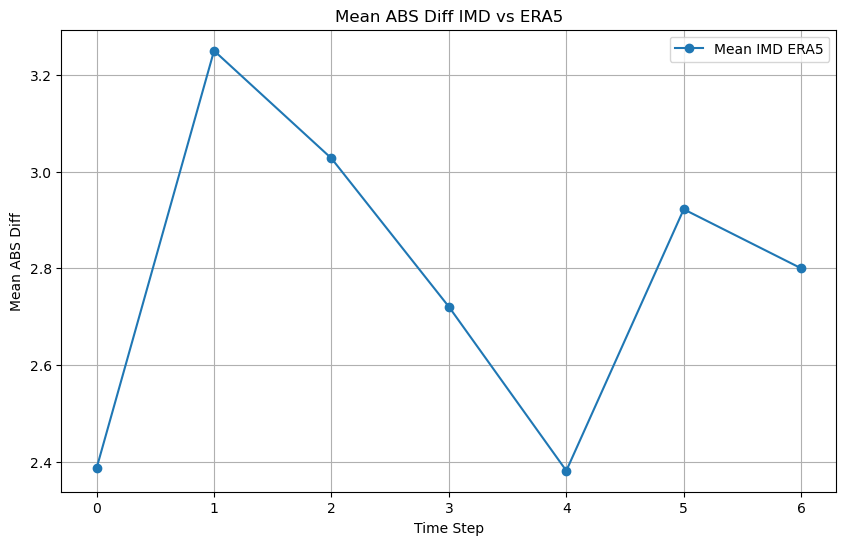

In [42]:
import matplotlib.pyplot as plt

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(time_steps, mse_imd_era5, label='Mean IMD ERA5', marker='o')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean ABS Diff')
plt.title('Mean ABS Diff IMD vs ERA5')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

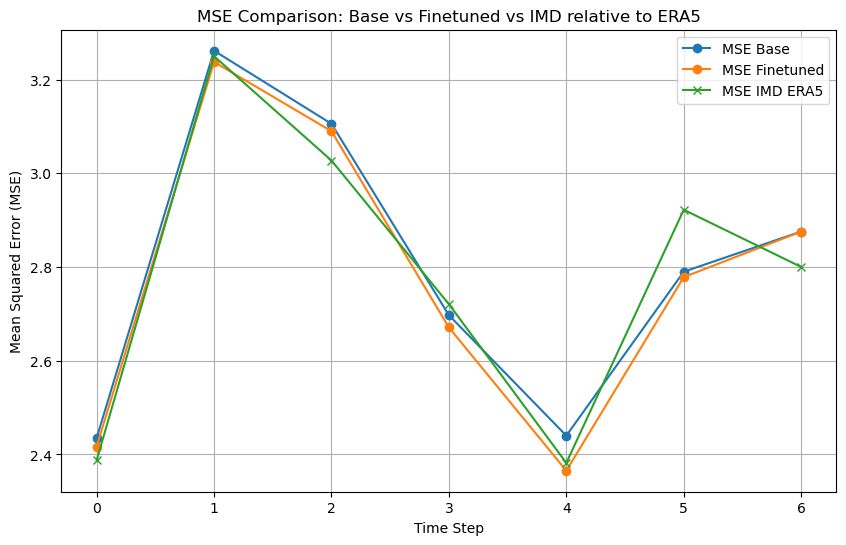

In [43]:
import matplotlib.pyplot as plt

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(time_steps, mse_base, label='MSE Base', marker='o')
plt.plot(time_steps, mse_finetuned, label='MSE Finetuned', marker='o')
plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE Comparison: Base vs Finetuned vs IMD relative to ERA5')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
# predictions_old['total_precipitation_6hr']

<xarray.DataArray 'total_precipitation_6hr' (time: 28, batch: 1, lat: 181,
                                             lon: 360)> Size: 7MB
array([[[[-4.817846e-06, ...,  7.941768e-06],
         ...,
         [ 4.853522e-05, ...,  4.899920e-05]]],


       ...,


       [[[-8.299948e-05, ..., -7.331380e-05],
         ...,
         [ 3.664558e-05, ...,  2.545191e-05]]]],
      shape=(28, 1, 181, 360), dtype=float32)
Coordinates:
  * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Dimensions without coordinates: batch

In [ ]:
# 

In [ ]:
# mse_base

[<xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77021.82208301)
 Coordinates:
     time     timedelta64[ns] 8B 06:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77240.19724821)
 Coordinates:
     time     timedelta64[ns] 8B 12:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77338.14011257)
 Coordinates:
     time     timedelta64[ns] 8B 18:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77262.54020194)
 Coordinates:
     time     timedelta64[ns] 8B 1 days,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77083.98556547)
 Coordinates:
     time     timedelta64[ns] 8B 1 days 06:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77222.73474306)
 Coordinates:
     time     timedelta64[ns] 8B 1 days 12:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77385.04703374)
 Coordinates:
     time     timedelta64[ns] 8B 1 days 18:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(77210.68494182)
 Coord

In [ ]:
# list(mse_finetuned)

[<xarray.DataArray '2m_temperature' ()> Size: 8B
 array(76583.80038269)
 Coordinates:
     time     timedelta64[ns] 8B 06:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(76423.62156832)
 Coordinates:
     time     timedelta64[ns] 8B 12:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(76198.23080123)
 Coordinates:
     time     timedelta64[ns] 8B 18:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(75886.97077074)
 Coordinates:
     time     timedelta64[ns] 8B 1 days,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(75442.95687943)
 Coordinates:
     time     timedelta64[ns] 8B 1 days 06:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(75321.37889736)
 Coordinates:
     time     timedelta64[ns] 8B 1 days 12:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(75257.86613048)
 Coordinates:
     time     timedelta64[ns] 8B 1 days 18:00:00,
 <xarray.DataArray '2m_temperature' ()> Size: 8B
 array(74913.15300418)
 Coord

In [11]:

# latmin = 8
# latmax = 37
# lonmin = 68
# lonmax = 97

# temperature_pred_finetuned

<xarray.DataArray '2m_temperature' (time: 28, batch: 1, lat: 181, lon: 360)> Size: 7MB
xarray_jax.JaxArrayWrapper(Array([[[[260.02774, 260.02264, 260.02264, ..., 260.05832, 260.03284,
          260.04813],
         [259.33575, 259.34085, 259.33066, ..., 259.37555, 259.3549 ,
          259.33423],
         [258.95764, 258.9363 , 258.91855, ..., 258.893  , 258.925  ,
          258.93533],
         ...,
         [223.22266, 223.16182, 223.08722, ..., 223.3095 , 223.29027,
          223.29123],
         [221.31192, 221.27646, 221.22136, ..., 221.44759, 221.3941 ,
          221.34344],
         [219.99782, 219.9991 , 219.98381, ..., 220.01437, 219.99146,
          219.9991 ]]],


       [[[261.6584 , 261.6533 , 261.67368, ..., 261.67877, 261.6533 ,
          261.67877],
         [260.67087, 260.66577, 260.69632, ..., 260.675  , 260.66962,
          260.66934],
         [260.20102, 260.1797 , 260.15683, ..., 260.15167, 260.17346,
...
          240.84142],
         [239.88771, 239.88419, 239.93616, ..., 240.02458, 239.93423,
          239.8848 ],
         [238.89455, 238.96217, 238.9485 , ..., 238.894  , 238.89162,
          238.94781]]],


       [[[276.12457, 276.14685, 276.1664 , ..., 276.14447, 276.13623,
          276.14764],
         [275.24915, 275.23575, 275.2442 , ..., 275.2419 , 275.24628,
          275.2438 ],
         [275.74387, 275.75034, 275.7423 , ..., 275.71808, 275.76013,
          275.754  ],
         ...,
         [241.07486, 241.03421, 240.90186, ..., 241.23381, 241.30266,
          241.27455],
         [240.2597 , 240.20395, 240.23044, ..., 240.49849, 240.3572 ,
          240.28482],
         [239.28693, 239.31123, 239.26826, ..., 239.40358, 239.36043,
          239.38605]]]], dtype=float32))
Coordinates:
  * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Dimensions without coordinates: batch

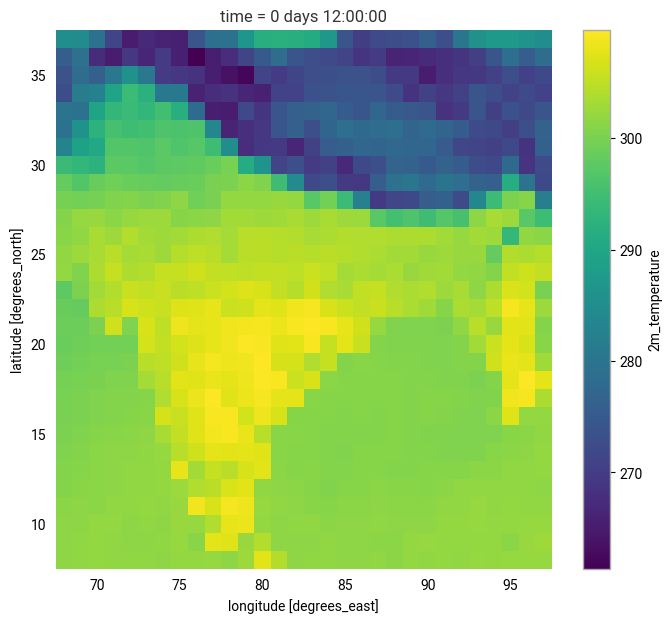

In [ ]:
# temperature_pred_finetuned.isel(time=1).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))

In [ ]:




# print("Starting subsetting:")
# for time_step in time_steps:    
#     temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
#     if time_step == 1:
#         print(temp_finetuned.dims)
#     temp_finetuned = temp_finetuned.squeeze()
    
#     temp_old = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
#     if time_step == 1:
    
#         print(temp_old.dims)
#     temp_old = temp_old.squeeze()

#     temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
#     if time_step == 1:
    
#         print(temp_targets.dims)
#     temp_targets = temp_targets.squeeze()

#     mse_finetuned.append(compute_mse(temp_finetuned, temp_targets))
#     mse_base.append(compute_mse(temp_old, temp_targets))

# # Compute the overall loss by averaging the MSE over all time steps
# overall_loss_finetuned = np.mean(mse_finetuned)
# overall_loss_base = np.mean(mse_base)

# print(f"Overall Loss (Finetuned Predictions): {overall_loss_finetuned}")
# print(mse_finetuned)
# print(f"Overall Loss (Base Predictions): {overall_loss_base}")
# print(mse_base)


# logger.info("Finished inference")

# # can add evaluation and comparison code here after testing everything for a few timesteps




# # </finetuning_cleaned.py>

Starting subsetting:
('batch', 'lat', 'lon')
('batch', 'lat', 'lon')
('batch', 'lat', 'lon')
Overall Loss (Finetuned Predictions): nan
[<xarray.DataArray '2m_temperature' ()> Size: 4B
xarray_jax.JaxArrayWrapper(Array(nan, dtype=float32))
Coordinates:
    time     timedelta64[ns] 8B 06:00:00, <xarray.DataArray '2m_temperature' ()> Size: 4B
xarray_jax.JaxArrayWrapper(Array(nan, dtype=float32))
Coordinates:
    time     timedelta64[ns] 8B 12:00:00, <xarray.DataArray '2m_temperature' ()> Size: 4B
xarray_jax.JaxArrayWrapper(Array(nan, dtype=float32))
Coordinates:
    time     timedelta64[ns] 8B 18:00:00, <xarray.DataArray '2m_temperature' ()> Size: 4B
xarray_jax.JaxArrayWrapper(Array(nan, dtype=float32))
Coordinates:
    time     timedelta64[ns] 8B 1 days, <xarray.DataArray '2m_temperature' ()> Size: 4B
xarray_jax.JaxArrayWrapper(Array(nan, dtype=float32))
Coordinates:
    time     timedelta64[ns] 8B 1 days 06:00:00, <xarray.DataArray '2m_temperature' ()> Size: 4B
xarray_jax.JaxArrayWrapper